In [134]:
import numpy as np
import pandas as pd
import arviz as az
from matplotlib import pyplot as plt
from cmdstanpy import CmdStanModel
from sampler import CycloneDataSimulator

In [ ]:
# test some prior parameters that I got from Claude:
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 2               # number of ocean basins
D = 5               # number of predictors
N = 2000             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [136]:
# compile Stan model
model = CmdStanModel(stan_file="conjugate_model.stan")

In [137]:
# fit and sample using Stan model
fit = model.sample(stan_data)
draws_df = fit.draws_pd()

19:32:35 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   5%|▌         | 100/2000 [00:09<03:05, 10.22it/s, (Warmup)]

chain 1:  10%|█         | 200/2000 [00:15<02:12, 13.60it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:20<01:46, 16.01it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:24<01:23, 19.05it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:32<01:36, 15.61it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:36<01:19, 17.57it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:40<01:05, 19.83it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:43<00:53, 22.33it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:47<00:46, 23.54it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:52<00:45, 21.83it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:57<00:42, 21.27it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [01:05<00:45, 17.48it/s, (Sampling)]


chain 1


19:34:24 - cmdstanpy - INFO - CmdStan done processing.
19:34:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


In [138]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

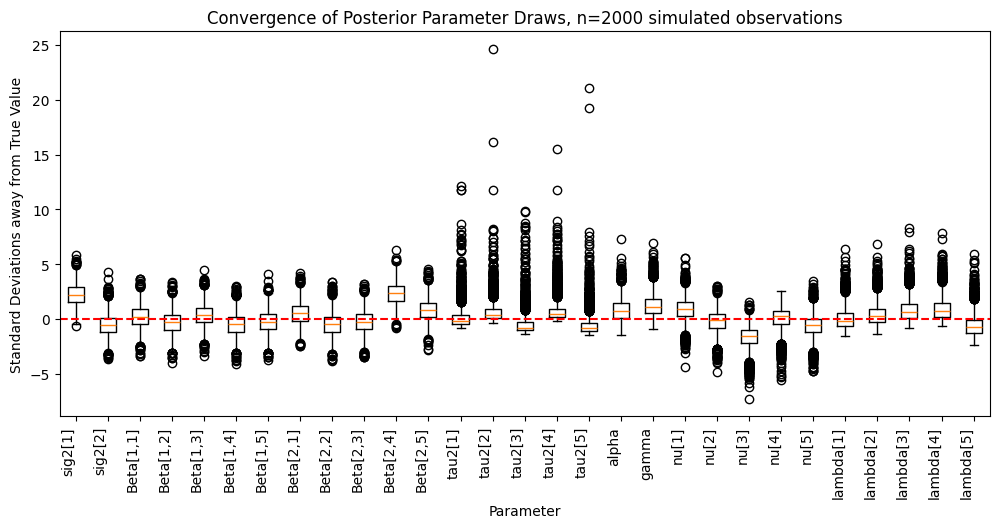

In [151]:
# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
all_param_draws = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[500:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)

plt.figure(figsize=(12, 5))
plt.boxplot(all_param_draws, tick_labels=param_names)
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Parameter")
plt.ylabel("Standard Deviations away from True Value")
plt.title(f"Convergence of Posterior Parameter Draws, n={N} simulated observations")
plt.show()

Try fewer observations to test sensitivity to sample size.

19:44:04 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:00<00:10, 175.72it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:01<00:09, 197.85it/s, (Warmup)]



chain 1:  15%|█▌        | 300/2000 [00:01<00:08, 210.60it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:01<00:06, 234.00it/s, (Warmup)]

chain 1:  25%|██▌       | 500/2000 [00:02<00:06, 248.94it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:02<00:05, 253.85it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:02<00:04, 280.82it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:03<00:04, 288.88it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:03<00:03, 315.35it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:04<00:06, 146.21it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:07<00:11, 79.75it/s, (Sampling)] 


chain 1:  60%|██████    | 1200/2000 [00:07<00:07, 100.54it/s, (Sampling


19:44:15 - cmdstanpy - INFO - CmdStan done processing.
19:44:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


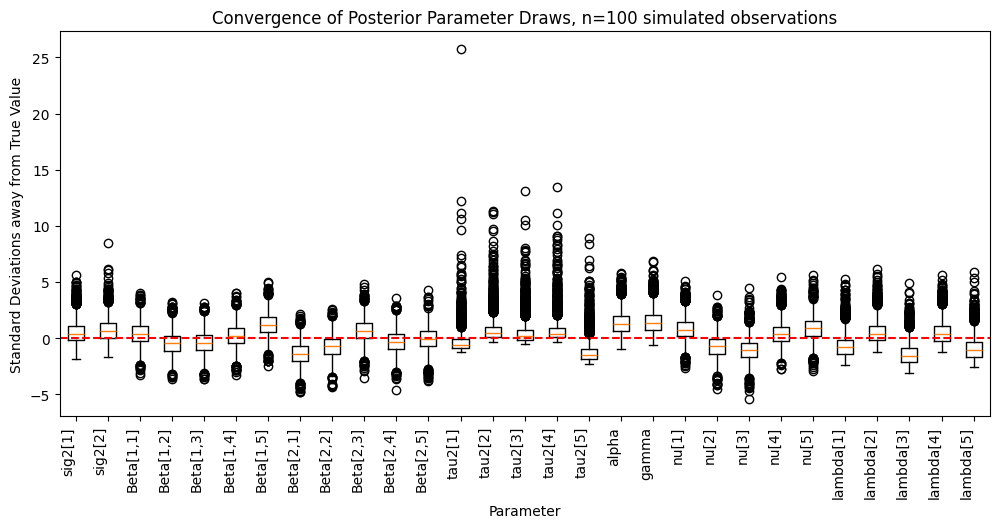

In [152]:
# hyperprior parameters
a = 1000
y_alpha = 1000
z_alpha = 50
y_gamma = 1000
z_gamma = 50 
v2 = 100
y_lam = 1000
z_lam = 50

# test some prior parameters that I got from Claude:
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 2               # number of ocean basins
D = 5               # number of predictors
N = 100             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

# fit and sample using Stan model
fit = model.sample(stan_data)
draws_df = fit.draws_pd()

param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
all_param_draws = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[50:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)

plt.figure(figsize=(12, 5))
plt.boxplot(all_param_draws, tick_labels=param_names)
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Parameter")
plt.ylabel("Standard Deviations away from True Value")
plt.title(f"Convergence of Posterior Parameter Draws, n={N} simulated observations")
plt.show()